# Лабораторная работа: бустинг

Цель работы — исследовать, как ведут себя методы бустинга при изменении основных параметров.

В отчете должны быть графики, таблицы и краткие выводы. Готовый шаблон кода не требуется.

---

## Задача 1. AdaBoost и сложность базовых деревьев

Возьмите двумерную задачу классификации, например `make_moons` или `make_circles`.

Сравните AdaBoost с базовыми деревьями разной глубины:

$$
\text{max\_depth}=1,\quad 2,\quad 3.
$$

Изменяйте число деревьев:

$$
M=5,\ 10,\ 20,\ 50,\ 100.
$$

### Что сделать

1. Постройте графики train/test accuracy от числа деревьев.
2. Для нескольких моделей нарисуйте границу классификации.
3. Опишите, как глубина дерева влияет на недообучение и переобучение.

---

## Задача 2. Learning rate и число деревьев

Возьмите задачу регрессии или классификации.

Обучите градиентный бустинг при разных learning rate:

$$
\nu=1.0,\ 0.3,\ 0.1,\ 0.03.
$$

Для каждого значения $\nu$ рассмотрите разные числа деревьев:

$$
M=10,\ 30,\ 100,\ 300.
$$

### Что сделать

1. Сравните качество на train и test.
2. Постройте графики ошибки от числа деревьев.
3. Найдите удачное сочетание $\nu$ и $M$.

### Что обсудить

1. Что происходит при слишком большом learning rate?
2. Почему маленький learning rate требует больше деревьев?
3. Где видно переобучение?

---

## Задача 3. Классический и histogram-based бустинг

Выберите один табличный датасет.

Сравните две реализации из `scikit-learn`:

- `GradientBoostingClassifier` или `GradientBoostingRegressor`;
- `HistGradientBoostingClassifier` или `HistGradientBoostingRegressor`.

### Что сделать

1. Сравните качество моделей на test.
2. Сравните время обучения.
3. Добавьте искусственные пропуски в данные.
4. Проверьте, какая модель может работать с `NaN` напрямую.

### Что обсудить

1. Чем histogram-based подход отличается от обычного?
2. Ускорилось ли обучение?
3. Как обработка пропусков повлияла на результат?

---

## Задача 4. XGBoost, LightGBM, CatBoost

Выберите один табличный датасет и сравните современные реализации бустинга:

- XGBoost;
- LightGBM;
- CatBoost.

Можно сравнить их также с `HistGradientBoosting`.

### Что сделать

1. Обучите 2–3 современные реализации бустинга.
2. Сравните качество на train и test.
3. Сравните время обучения.
4. Проверьте работу с пропусками.
5. Если в данных есть категориальные признаки, сравните способы их обработки.

### Что обсудить

1. Чем XGBoost отличается от обычного gradient boosting?
2. Какие особенности LightGBM удалось увидеть в эксперименте?
3. Удобен ли CatBoost для категориальных признаков?
4. Какая реализация оказалась лучшей по балансу качества, скорости и удобства?

---

## Итоговый вывод

В конце работы кратко ответьте:

1. Какие параметры бустинга оказались наиболее важными?
2. Где наблюдалось переобучение?
3. Какая модель показала лучший баланс качества, скорости и простоты?

# Задача 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [4]:
X, y = make_moons(n_samples=1000, random_state=42, noise=0.25)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
depths = [1, 2, 3]
n_estimators_list = [5, 10, 20, 50, 100]

results = {}

In [6]:
for depth in depths:

    train_scores = []
    test_scores = []

    for n_estimators in n_estimators_list:

        base_tree = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )

        model = AdaBoostClassifier(
            estimator=base_tree,
            n_estimators=n_estimators,
            random_state=42
        )

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        train_scores.append(train_acc)
        test_scores.append(test_acc)

        print(
            f"depth={depth}, "
            f"M={n_estimators}, "
            f"train={train_acc:.3f}, "
            f"test={test_acc:.3f}"
        )

    results[depth] = {
        "train": train_scores,
        "test": test_scores
    }

depth=1, M=5, train=0.909, test=0.903
depth=1, M=10, train=0.904, test=0.897
depth=1, M=20, train=0.907, test=0.900
depth=1, M=50, train=0.951, test=0.950
depth=1, M=100, train=0.959, test=0.950
depth=2, M=5, train=0.933, test=0.927
depth=2, M=10, train=0.960, test=0.960
depth=2, M=20, train=0.963, test=0.953
depth=2, M=50, train=0.966, test=0.950
depth=2, M=100, train=0.977, test=0.943
depth=3, M=5, train=0.950, test=0.927
depth=3, M=10, train=0.959, test=0.933
depth=3, M=20, train=0.974, test=0.950
depth=3, M=50, train=1.000, test=0.943
depth=3, M=100, train=1.000, test=0.937


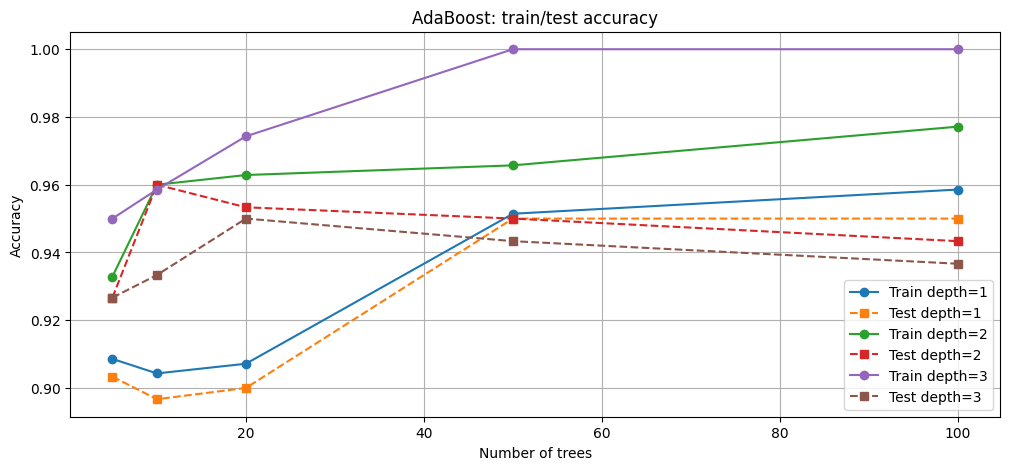

In [7]:
plt.figure(figsize=(12, 5))

for depth in depths:

    plt.plot(
        n_estimators_list,
        results[depth]["train"],
        marker='o',
        label=f"Train depth={depth}"
    )

    plt.plot(
        n_estimators_list,
        results[depth]["test"],
        marker='s',
        linestyle='--',
        label=f"Test depth={depth}"
    )

plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.title("AdaBoost: train/test accuracy")
plt.legend()
plt.grid(True)

plt.show()

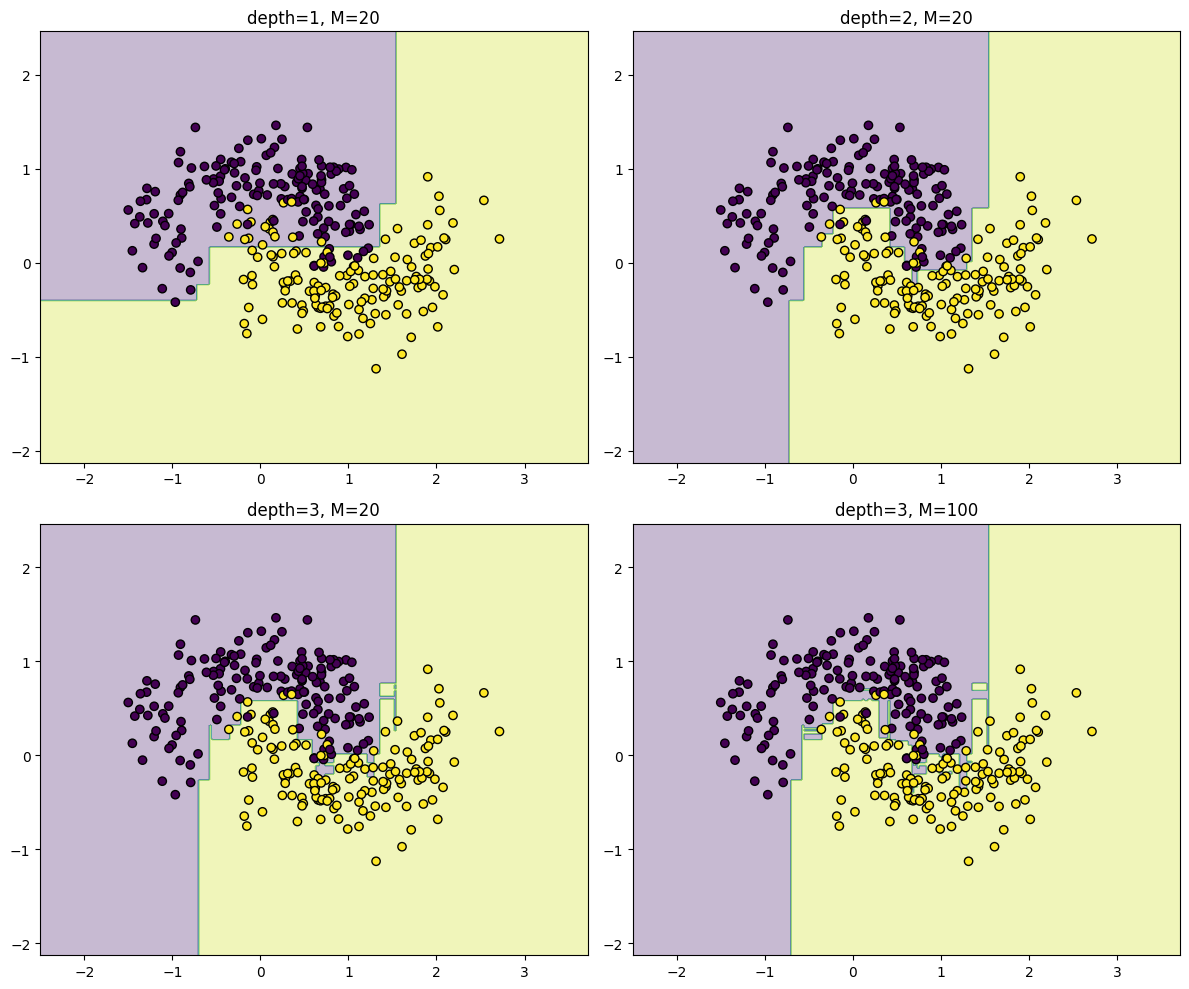

In [8]:
def plot_decision_boundary(model, X, y, title):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = model.predict(grid)
    probs = probs.reshape(xx.shape)

    plt.contourf(xx, yy, probs, alpha=0.3)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors='k'
    )

    plt.title(title)


configs = [
    (1, 20),
    (2, 20),
    (3, 20),
    (3, 100)
]

plt.figure(figsize=(12, 10))

for i, (depth, n_estimators) in enumerate(configs, 1):

    base_tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=n_estimators,
        random_state=42
    )

    model.fit(X_train, y_train)

    plt.subplot(2, 2, i)

    plot_decision_boundary(
        model,
        X_test,
        y_test,
        f"depth={depth}, M={n_estimators}"
    )

plt.tight_layout()
plt.show()

# Задача 2

# Задача 3

# Задача 4